Code for Neural Gibbs sampling, applied to the contour inference problem in Chapter 5 of Computational Foundations of Cognitive Neuroscience (https://gershmanlab.com/textbook/chapter5.pdf)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [10]:
# set random seed for reproducibility
random.seed(40)

In [11]:
def run_spiking_inference(size=12, T_steps=500, noise_std=0.3, contour_width=2):
    # 1. Set up orientations (discretized into J bins)
    J = 16
    nu = 1.5        # Tuning width
    H_val = 2.0     # Lateral coupling strength (prior)
    dt = 0.1
    N = size**2

    angles = np.linspace(0, np.pi, J, endpoint=False) # Orientations

    # 2. Create the Fields
    X, Y = np.meshgrid(np.arange(size), np.arange(size))

    # BACKGROUND: Smoothly varying spatial gradient
    bg_field = (np.pi/2) * np.sin(X/8.0) + (np.pi/4) * np.cos(Y/10.0)
    bg_field %= np.pi

    # CONTOUR: A wide diagonal ribbon (y = x +/- width)
    true_field = bg_field.copy()
    contour_angle = np.pi / 4
    # Logic: pixels where the distance from the diagonal is small
    contour_mask = np.abs(X - Y) <= contour_width
    true_field[contour_mask] = contour_angle

    # 3. Generate Input with high Signal-to-Noise Ratio
    noisy_input = (true_field + np.random.normal(0, noise_std, (size, size))) % np.pi

    # We give the contour pixels a higher base firing rate to simulate "saliency"
    input_rates = np.zeros((size, size, J))
    base_rate = 10
    for r in range(size):
        for c in range(size):
            input_rates[r, c, :] = base_rate * np.exp((1/nu) * np.cos(2 * (angles - noisy_input[r, c])))

    # 4. Neural Simulation
    mu = np.zeros((N, J))
    y_spikes = np.zeros((N, J))

    # Nearest neighbor connectivity
    H = np.zeros((N, N))
    for i in range(N):
        r, c = divmod(i, size)
        for dr, dc in [(-1,0), (1,0), (0,-1), (0,1)]:
            nr, nc = r+dr, c+dc
            if 0 <= nr < size and 0 <= nc < size:
                H[i, nr * size + nc] = H_val

    for t in range(T_steps):
        z = np.random.poisson(input_rates.reshape(N, J) * dt)

        # 1. Compute Feedforward Input (FF)
        # Each output neuron j integrates spikes from all sensory neurons k,
        # weighted by the cosine of their orientation difference.
        # We use 'cos_diff' to represent cos(s_j - s_k)
        cos_diff_ff = np.cos(2 * (angles[:, None] - angles[None, :]))
        ff_input = (1/nu) * (z @ cos_diff_ff.T)

        # 2. Compute Lateral Input (Lat)
        # Same logic for neighboring output neurons y_spikes
        lat_input = (H @ y_spikes) @ cos_diff_ff.T

        # 3. Update Membrane Potential
        mu += (ff_input + lat_input) * dt

        # Sample via Softmax
        exp_mu = np.exp(mu - np.max(mu, axis=1, keepdims=True))
        rho = exp_mu / np.sum(exp_mu, axis=1, keepdims=True)
        y_spikes = (np.random.rand(N, J) < rho).astype(float)

    inferred_field = angles[np.argmax(mu, axis=1)].reshape(size, size)
    return true_field, noisy_input, inferred_field

def plot_vectors(ax, field, title, color='black', alpha=1.0):
    size = field.shape[0]
    X, Y = np.meshgrid(np.arange(size), np.arange(size))
    U, V = np.cos(field), np.sin(field)
    ax.quiver(X, Y, U, V, color=color, pivot='mid', alpha=alpha,
              headwidth=0, headlength=0, headaxislength=0, width=0.009)
    ax.set_title(title, fontsize=14)
    ax.set_aspect('equal')
    ax.axis('off')

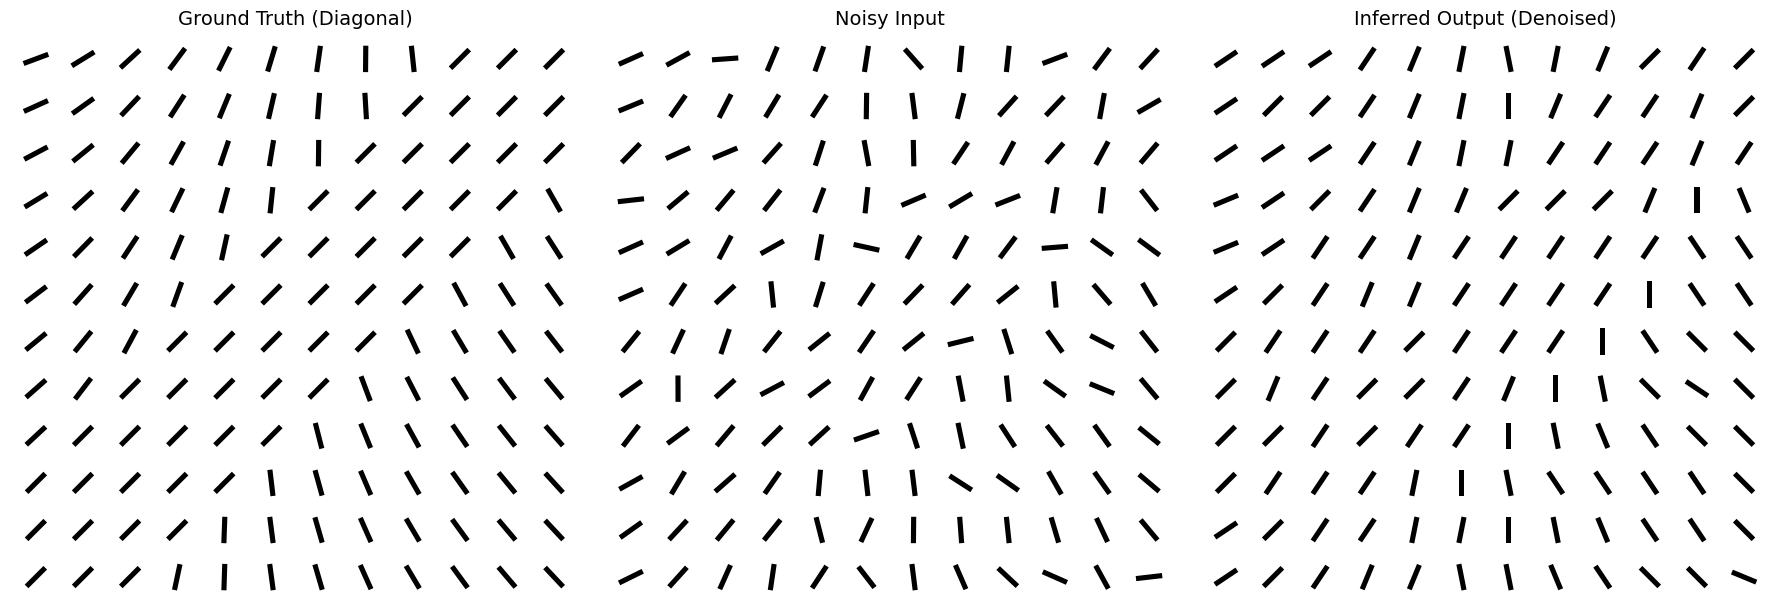

In [ ]:
# Run and visualize
gt, noise, result = run_spiking_inference()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_vectors(axes[0], gt, "Ground Truth (Diagonal)")
plot_vectors(axes[1], noise, "Noisy Input")
plot_vectors(axes[2], result, "Inferred Output (Denoised)")
plt.tight_layout()
plt.show()